In [3]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np

from config import *
from pandas.api.types import CategoricalDtype
import scipy.sparse as sparse
import matplotlib.pyplot as plt

In [4]:
orders = pd.read_parquet(ORDERS_PATH)
order_products = pd.read_parquet(ORDER_PRODUCTS__PRIOR_PATH)
products = pd.read_parquet(PRODUCTS_PATH)
departments = pd.read_parquet(DEPARTMENTS_PATH)

product_department = products.merge(departments, on='department_id', how='inner')

In [4]:
ratings_long = pd.read_parquet(DATA_PREPROCESSED_DIR / "ratings_w_freq-0.33_w_rec-0.33_w_tfidf-0.33.pq")
ratings_department_long = (ratings_long
 .merge(product_department, how='inner', left_on='item', right_on='product_id')
 .groupby(["user", "department_id"])["rating"]
 .mean()
 .reset_index()
)
ratings_department_long.columns = ["user", "item", "rating"]
ratings_department_long

,user,item,rating
0,12,8,0.069774
1,14,13,0.027200
2,17,14,0.010369
3,19,1,0.196359
4,23,7,0.089251
...,...,...,...
9934,206085,16,0.144782
9935,206086,3,0.043564
9936,206102,19,0.061869
9937,206199,19,0.076828


In [5]:

users = ratings_department_long["user"].unique()
item = ratings_department_long["item"].unique()
shape = (len(users), len(item))

# Create indices for users and movies
user_cat = CategoricalDtype(categories=sorted(users), ordered=True)
product_cat = CategoricalDtype(categories=sorted(item), ordered=True)
user_index = ratings_department_long["user"].astype(user_cat).cat.codes
product_index = ratings_department_long["item"].astype(product_cat).cat.codes

# Conversion via COO matrix
coo = sparse.coo_matrix((ratings_department_long["rating"], (user_index, product_index)), shape=shape)
ratings_matrix = coo.tocsr()

In [6]:
dbscan = DBSCAN()

preds = dbscan.fit_predict(ratings_matrix)


In [7]:
pca = PCA(n_components=2)


X_pca = pca.fit_transform(ratings_matrix)




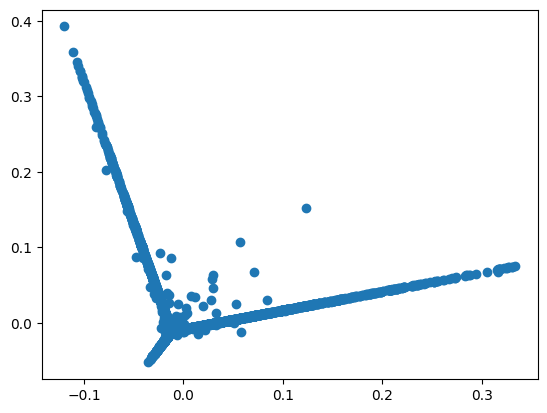

In [8]:
plt.scatter(X_pca[:,0], X_pca[:,1])

In [9]:
from umap import UMAP


umap = UMAP(metric='manhattan')

X_umap = umap.fit_transform(ratings_matrix)



/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
umap = UMAP(min_dist=0, n_neighbors=5)
X_umap = umap.fit_transform(ratings_matrix)


In [132]:
pd.DataFrame(ratings_matrix.toarray())

,0,1,2,3,4,5,6,7,8,9,...,124,125,126,127,128,129,130,131,132,133
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.010369,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.196359,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9578,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
9579,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
9580,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
9581,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0


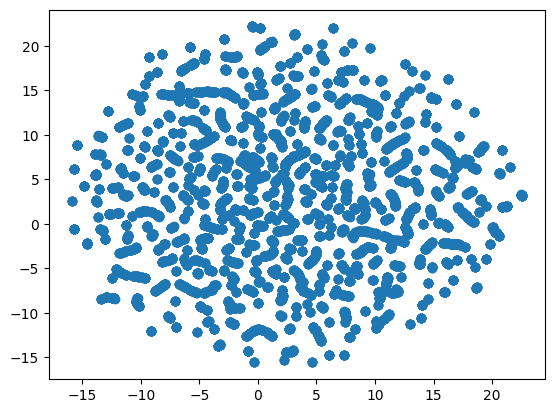

In [14]:
plt.scatter(X_umap[:,0], X_umap[:,1])

In [13]:
dbscan.fit_predict(X_umap)

array([  0,   1,   2, ...,  15, 172,  61])

In [10]:
import pandas as pd
order_products_train = pd.read_parquet(ORDER_PRODUCTS__TRAIN_PATH)

In [5]:
products

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
...,...,...,...,...
49683,49684,"Vodka, Triple Distilled, Twist of Vanilla",124,5
49684,49685,En Croute Roast Hazelnut Cranberry,42,1
49685,49686,Artisan Baguette,112,3
49686,49687,Smartblend Healthy Metabolism Dry Cat Food,41,8


In [14]:
orders[orders["order_id"] == 1492625]

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
25,1492625,2,train,15,1,11,30.0


In [16]:
order_products_train[order_products_train["order_id"] == 1492625]

,order_id,product_id,add_to_cart_order,reordered
606747,1492625,22963,1,1
606748,1492625,7963,2,1
606749,1492625,16589,3,1
606750,1492625,32792,4,1
606751,1492625,41787,5,1
606752,1492625,22825,6,1
606753,1492625,13640,7,0
606754,1492625,24852,8,1
606755,1492625,45066,9,1
606756,1492625,9387,10,0
